# S04.08 — K-Means
## Módulo 3, Tema 1: Introducción a Machine Learning — Subtema 4

**Técnica:** K-Means (particional, `sklearn.cluster.KMeans`)
**Tarea:** aprendizaje **no supervisado** — segmentación de cartera por perfil de emisión
**Dataset:** Sintético v2 — 30,000 pólizas de seguros de autos
**Variables de clustering:** `CLUSTERING_FEATURES` (`edad`, `suma_asegurada`, `num_renovaciones`, `antiguedad_vehiculo`)

---

## 1. Contexto actuarial

Hasta ahora las técnicas de este módulo fueron **supervisadas**: existía una variable objetivo
(`prima_neta`, `siniestro_alto`) y el modelo aprendía a predecirla. El **clustering** es
**no supervisado**: no hay variable objetivo. El objetivo es descubrir **grupos** de pólizas con
perfiles similares en el espacio de features.

### 1.1 ¿Para qué sirve en seguros?

- **Segmentación de cartera** por perfil de emisión: agrupar pólizas parecidas para diseño de
  productos, comunicación diferenciada o priorización operativa.
- **Exploración previa** a la tarificación: entender la heterogeneidad de la cartera.

Los segmentos son **descriptivos**: no son una tarifa ni una clase de riesgo por sí solos.

### 1.2 Regla de datos (sin targets en el ajuste)

El clustering se ajusta **únicamente** con `CLUSTERING_FEATURES`. Se excluyen `id_poliza_sin` y
**todas** las variables target (`prima_neta`, `n_siniestros`, `monto_siniestro`, `siniestro_alto`,
`status_poliza`). Comparar los clusters con los targets es un **análisis posterior** de
interpretación — esos targets **no** forman los clusters.

### 1.3 Sobre la estructura del dataset

El proceso generador del dataset sintético induce **tendencias** en el espacio de features (por
correlaciones de diseño entre edad, renovaciones, suma asegurada y antigüedad). Sin embargo, **no
existen etiquetas verdaderas de segmento** ni una partición "correcta": el clustering agrupa por
similitud, y **no hay garantía** de que recupere ninguna estructura latente concreta. Cualquier
correspondencia con perfiles esperados debe tratarse como interpretación, no como validación.

> *Fuentes principales:* Unpingco (2022) §4.10; ESL Cap. 14 §14.3.6–§14.3.9; ISLP Cap. 12 §12.4.1.

## 2. Fundamento matemático

### 2.1 Función objetivo

K-Means busca una partición $\mathcal{C}=\{C_1,\dots,C_K\}$ y centroides
$\boldsymbol{\mu}_1,\dots,\boldsymbol{\mu}_K$ que minimizan la **inercia** (suma de cuadrados
intra-cluster, WCSS):

$$J(\mathcal{C},\boldsymbol{\mu}) = \sum_{k=1}^{K}\sum_{\mathbf{x}_i\in C_k}\|\mathbf{x}_i-\boldsymbol{\mu}_k\|^2$$

### 2.2 Algoritmo de Lloyd

Alterna dos pasos hasta estabilizar las asignaciones:

1. **Asignación:** cada $\mathbf{x}_i$ se asigna al cluster con centroide más cercano.
2. **Actualización:** cada centroide es la media de sus puntos:
$$\boldsymbol{\mu}_k = \frac{1}{|C_k|}\sum_{\mathbf{x}_i\in C_k}\mathbf{x}_i$$

Cada iteración no aumenta $J$ → converge a un **mínimo local** (no necesariamente global).

### 2.3 Inicialización k-means++

La solución depende de la inicialización. **k-means++** siembra centroides bien separados
(cada centroide se elige con probabilidad proporcional a la distancia² al centroide más cercano
ya elegido). Es la opción por defecto de scikit-learn. El parámetro `n_init` repite el ajuste
con distintas siembras y conserva la de mejor inercia.

In [15]:
import sys
from pathlib import Path

_candidates = [Path.cwd() / "", Path.cwd().parent / "", Path.cwd().parent.parent / ""]
_src_path = next((p for p in _candidates if (p / "simulate_portfolio_v2.py").exists()), None)
if _src_path is None:
    raise FileNotFoundError(
        "No se encontró simulate_portfolio_v2.py. "
        "Ejecutar desde la raíz del proyecto o desde content/notebooks/."
    )
sys.path.insert(0, str(_src_path))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import simulate_portfolio_v2

importlib.reload(simulate_portfolio_v2)


from simulate_portfolio_v2 import (
    simulate_auto_insurance_portfolio_v2,
    FEATURE_COLUMNS, TARGET_COLUMNS, CLUSTERING_FEATURES,
)

SEED = 20260618
N    = 30_000
NAVY = "#003B5C"; GOLD = "#C8A33A"; RED = "#C0392B"; GREEN = "#2E7D44"
CLUSTER_COLORS = ["#003B5C", "#C8A33A", "#2E7D44", "#C0392B", "#6A5ACD", "#008B8B", "#B8860B"]

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

df = simulate_auto_insurance_portfolio_v2(n_policies=N, seed=SEED)
print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")

# ── Regla de seguridad: el clustering NUNCA usa targets ni identificadores ────
assert set(CLUSTERING_FEATURES).isdisjoint(set(TARGET_COLUMNS)), \
    "CLUSTERING_FEATURES no debe intersecar TARGET_COLUMNS"
assert "id_poliza_sin" not in CLUSTERING_FEATURES, "id_poliza_sin no es feature de clustering"
assert set(CLUSTERING_FEATURES).issubset(set(FEATURE_COLUMNS)), \
    "CLUSTERING_FEATURES debe ser subconjunto de FEATURE_COLUMNS"
print("Variables de clustering (canonicas):", CLUSTERING_FEATURES)
print("Excluidas del ajuste: id_poliza_sin y todos los targets:", TARGET_COLUMNS)
print("Verificacion CLUSTERING_FEATURES ∩ TARGET_COLUMNS = vacio: OK")


Dataset cargado: 30,000 filas x 23 columnas
Variables de clustering (canonicas): ['edad', 'suma_asegurada', 'num_renovaciones', 'antiguedad_vehiculo', 'kilometraje']
Excluidas del ajuste: id_poliza_sin y todos los targets: ['prima_neta', 'n_siniestros', 'monto_siniestro', 'siniestro_alto', 'status_poliza']
Verificacion CLUSTERING_FEATURES ∩ TARGET_COLUMNS = vacio: OK


## 3. Preparación: escalamiento y distancias

K-Means minimiza distancias euclidianas. Sin escalar, `suma_asegurada` (∼10⁵) domina a
`num_renovaciones` (0–5). `StandardScaler` estandariza cada variable (observación $i$, feature $j$):

$$x'_{ij} = \frac{x_{ij}-\mu_j}{\sigma_j}$$

donde $\mu_j$ y $\sigma_j$ son la media y desviación estándar de la feature $j$ (estimadas sobre
los datos ajustados). Así todas las variables contribuyen de forma comparable a la distancia.

In [16]:
from sklearn.preprocessing import StandardScaler

# Espacio de clustering canonico: 4 variables numericas escaladas
X = StandardScaler().fit_transform(df[CLUSTERING_FEATURES].to_numpy(dtype=float))
print(f"Matriz de clustering X: {X.shape[0]:,} x {X.shape[1]} (features escaladas)")
print("Media por columna (≈0):", np.round(X.mean(axis=0), 3))
print("Desv. std por columna (≈1):", np.round(X.std(axis=0), 3))


Matriz de clustering X: 30,000 x 5 (features escaladas)
Media por columna (≈0): [ 0.  0. -0.  0.  0.]
Desv. std por columna (≈1): [1. 1. 1. 1. 1.]


## 3b. Efecto del one-hot encoding de variables categóricas sobre las distancias

Si añadimos variables **categóricas** mediante one-hot encoding, cada categoría se convierte en
un eje binario 0/1: dos categorías distintas quedan a distancia √2 y dos iguales a distancia 0.
Eso puede **dominar o diluir** la señal numérica según cuántas columnas binarias se agreguen.
A continuación comparamos el silhouette del espacio canónico (4 numéricas) frente a un espacio
extendido que añade el OHE de `plan` y `tipo_vehiculo` (ambas dentro de `FEATURE_COLUMNS`,
nunca targets).

Espacio extendido (num + OHE): 13 dimensiones


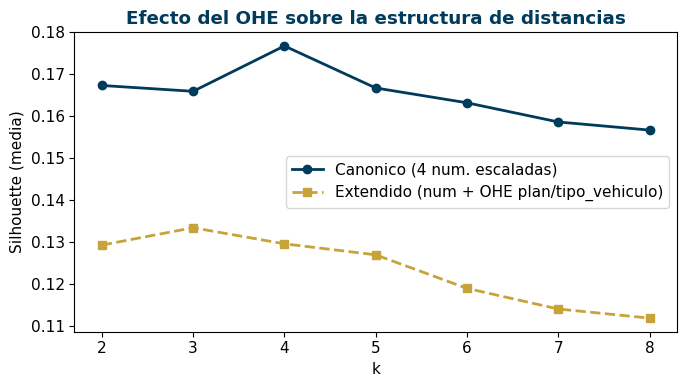

Decision de este material: espacio canonico numerico escalado como configuracion base.


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = list(range(2, 9)) #rango de grupos que pensamos saldran, 10 grupos ya es mucho
# si supera los 10, muchos clusters, convendria usar u modelo supervisado
SILH_SAMPLE = 5_000

OHE_CATS = ["plan", "tipo_vehiculo"] #variables a analizar ¿?
assert set(OHE_CATS).issubset(set(FEATURE_COLUMNS))
assert set(OHE_CATS).isdisjoint(set(TARGET_COLUMNS))

ext_pre = ColumnTransformer([
    ("num", StandardScaler(), CLUSTERING_FEATURES),
    ("cat", OneHotEncoder(drop=None, handle_unknown="ignore", sparse_output=False), OHE_CATS),
])
X_ext = ext_pre.fit_transform(df[CLUSTERING_FEATURES + OHE_CATS])
print(f"Espacio extendido (num + OHE): {X_ext.shape[1]} dimensiones")

sil_canon, sil_ext = [], []
for k in K_RANGE:
    lc = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X)
    le = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X_ext)
    sil_canon.append(silhouette_score(X, lc, sample_size=SILH_SAMPLE, random_state=SEED))
    sil_ext.append(silhouette_score(X_ext, le, sample_size=SILH_SAMPLE, random_state=SEED))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_RANGE, sil_canon, "o-", color=NAVY, lw=2, label="Canonico (4 num. escaladas)")
ax.plot(K_RANGE, sil_ext, "s--", color=GOLD, lw=2, label="Extendido (num + OHE plan/tipo_vehiculo)")
ax.set_xlabel("k"); ax.set_ylabel("Silhouette (media)")
ax.set_title("Efecto del OHE sobre la estructura de distancias", color=NAVY, fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()
print("Decision de este material: espacio canonico numerico escalado como configuracion base.")
# lo ideal es que ambas graficas tengan el maximo en el mismo k
# para ello se tiene que jugar con las colunmas features, ver que combinaciones me sirven para optimizar esta parte


## 4. Selección de k: inercia (codo) y silhouette; estabilidad como comprobación posterior

La **selección de k** se basa en el codo de la inercia y en el silhouette:
- **Inercia (codo):** la inercia siempre decrece con k; se busca el punto de **máxima distancia a
  la cuerda** (heurística del codo — no una curvatura exacta), que solo **sugiere** un k candidato.
- **Silhouette:** cohesión vs separación; se maximiza.

La **estabilidad** es una **comprobación posterior** (no seleccionó k): concordancia (ARI) entre
**ajustes con distinto `random_state`, cada uno con `n_init=10`**, sobre las **mismas** 30,000
observaciones. Cuantificar la estabilidad de cada k requeriría repetir este cálculo para cada k.

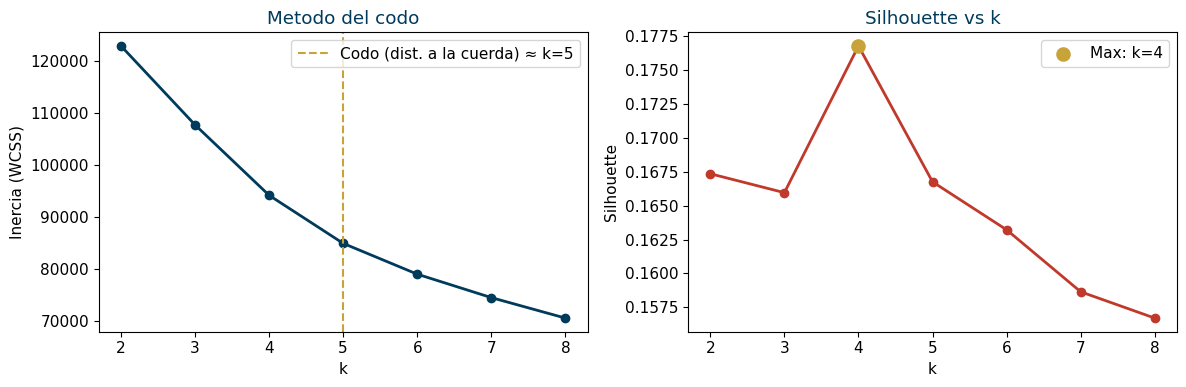

Codo (maxima distancia a la cuerda) sugiere k ≈ 5
Silhouette maximo en k=4 (silhouette=0.1768)
k seleccionada por codo + silhouette (la estabilidad se comprueba a continuacion).


In [18]:
def knee_index(y: np.ndarray) -> int:
    """Indice del punto de maxima distancia a la cuerda (determinista).

    Sobre una curva monotona ordenada, devuelve el indice del punto mas alejado de la
    recta que une el primer y el ultimo punto. Es una HEURISTICA del codo: solo sugiere
    un valor candidato, no una curvatura exacta ni una frontera cierta.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    x = np.arange(n, dtype=float)
    x1, x2, y1, y2 = x[0], x[-1], y[0], y[-1]
    num = np.abs((y2 - y1) * x - (x2 - x1) * y + x2 * y1 - y2 * x1)
    den = np.hypot(y2 - y1, x2 - x1)
    d = num / (den if den > 0 else 1.0)
    return int(np.argmax(d))


km_inertia, km_silhouette = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    lab = km.fit_predict(X)
    km_inertia.append(float(km.inertia_))
    km_silhouette.append(float(silhouette_score(X, lab, sample_size=SILH_SAMPLE, random_state=SEED)))

best_k = int(K_RANGE[int(np.argmax(km_silhouette))])
best_sil = float(max(km_silhouette))
elbow_k = int(K_RANGE[knee_index(np.array(km_inertia))])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_RANGE, km_inertia, "o-", color=NAVY, lw=2)
ax1.axvline(elbow_k, color=GOLD, ls="--", label=f"Codo (dist. a la cuerda) ≈ k={elbow_k}")
ax1.set_xlabel("k"); ax1.set_ylabel("Inercia (WCSS)"); ax1.set_title("Metodo del codo", color=NAVY); ax1.legend()
ax2.plot(K_RANGE, km_silhouette, "o-", color=RED, lw=2)
ax2.scatter([best_k], [best_sil], s=90, color=GOLD, zorder=5, label=f"Max: k={best_k}")
ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette"); ax2.set_title("Silhouette vs k", color=NAVY); ax2.legend()
plt.tight_layout(); plt.show()

print(f"Codo (maxima distancia a la cuerda) sugiere k ≈ {elbow_k}")
print(f"Silhouette maximo en k={best_k} (silhouette={best_sil:.4f})")
print("k seleccionada por codo + silhouette (la estabilidad se comprueba a continuacion).")


In [19]:
from sklearn.metrics import adjusted_rand_score

# Estabilidad (comprobacion POSTERIOR): ARI entre ajustes con distinto random_state,
# cada uno con n_init=10, sobre las MISMAS 30,000 observaciones (ARI exige mismas obs.).
ref_lab = KMeans(n_clusters=best_k, n_init=10, random_state=SEED).fit_predict(X)
stab_aris = []
for s in (SEED + 1, SEED + 2, SEED + 3, SEED + 4, SEED + 5):
    lab_s = KMeans(n_clusters=best_k, n_init=10, random_state=s).fit_predict(X)
    stab_aris.append(float(adjusted_rand_score(ref_lab, lab_s)))
stab_ari_mean = float(np.mean(stab_aris))
print(f"Estabilidad — ARI medio entre {len(stab_aris)} ajustes con distinto random_state "
      f"(k={best_k}, n_init=10): {stab_ari_mean:.4f}")
print("(1.0 = particion identica entre ajustes; indica reproducibilidad de la solucion para el k ya")
print(" seleccionado bajo las semillas evaluadas; no selecciona k por si sola.)")
print(f"K-MEANS seleccion final: k={best_k}")


Estabilidad — ARI medio entre 5 ajustes con distinto random_state (k=4, n_init=10): 0.9754
(1.0 = particion identica entre ajustes; indica reproducibilidad de la solucion para el k ya
 seleccionado bajo las semillas evaluadas; no selecciona k por si sola.)
K-MEANS seleccion final: k=4


## 5. Ajuste final y proyección PCA

Ajustamos K-Means con la k seleccionada y proyectamos a 2D con PCA **solo para visualizar**.
La proyección es **interpretativa**: el ajuste ocurrió en el espacio completo de 4 dimensiones,
no en las 2 componentes.

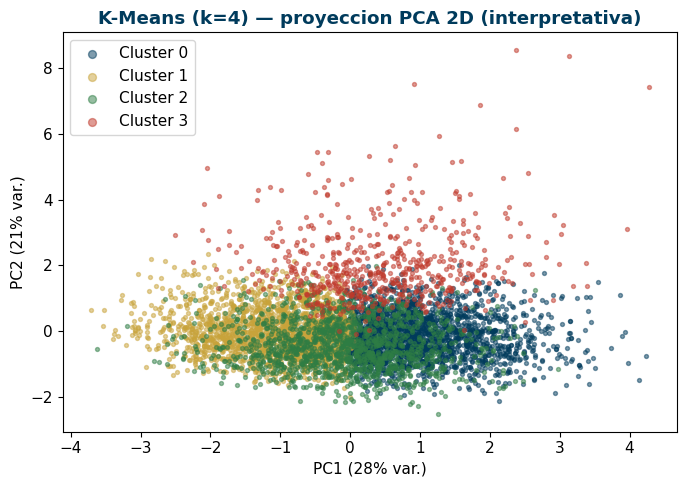

Inercia final (k=4): 94226.04
PC1+PC2 explican 49% de la varianza
Tamanos de cluster: [np.int64(9675), np.int64(9901), np.int64(7505), np.int64(2919)]


In [20]:
from sklearn.decomposition import PCA

km_final = KMeans(n_clusters=best_k, n_init=10, random_state=SEED)
km_labels = km_final.fit_predict(X)
km_inertia_final = float(km_final.inertia_)
km_sizes = pd.Series(km_labels).value_counts().sort_index()

pca = PCA(n_components=2, random_state=SEED).fit(X)
X_pca = pca.transform(X)
pca_var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 5))
rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_pca), size=6000, replace=False)
for c in range(best_k):
    m = km_labels[idx] == c
    ax.scatter(X_pca[idx][m, 0], X_pca[idx][m, 1], s=8, alpha=0.5,
               color=CLUSTER_COLORS[c % len(CLUSTER_COLORS)], label=f"Cluster {c}")
ax.set_xlabel(f"PC1 ({pca_var[0]*100:.0f}% var.)"); ax.set_ylabel(f"PC2 ({pca_var[1]*100:.0f}% var.)")
ax.set_title(f"K-Means (k={best_k}) — proyeccion PCA 2D (interpretativa)", color=NAVY, fontweight="bold")
ax.legend(markerscale=2); plt.tight_layout(); plt.show()

print(f"Inercia final (k={best_k}): {km_inertia_final:.2f}")
print(f"PC1+PC2 explican {(pca_var[0]+pca_var[1])*100:.0f}% de la varianza")
print("Tamanos de cluster:", list(km_sizes.values))


## 6. Perfilado de segmentos en unidades originales

Describimos cada cluster con las **medias en unidades originales** de las variables de clustering.
Luego, como **análisis posterior de interpretación**, comparamos los segmentos contra algunos
targets. **Importante:** esos targets **no** formaron los clusters; solo verificamos si los
segmentos descubiertos tienen lectura de negocio (sin afirmar que correspondan a segmentos "reales").

In [ ]:
prof = df[CLUSTERING_FEATURES].copy()
prof["cluster"] = km_labels
profile_orig = prof.groupby("cluster").mean().round(1)
profile_orig["n"] = km_sizes.values
print("Perfil de cada cluster (unidades originales):")
print(profile_orig.to_string())
# hasta aqui solo se clasifico, on se han hecho predicciones


Perfil de cada cluster (unidades originales):
         edad  suma_asegurada  num_renovaciones  antiguedad_vehiculo  kilometraje     n
cluster                                                                                
0        50.6        267053.7               2.7                  4.4      15509.4  9675
1        34.0        261818.9               1.2                  4.1      19206.9  9901
2        41.6        272624.4               1.8                 13.2      17072.7  7505
3        41.6        831374.9               2.3                  6.2      17537.5  2919


In [8]:
# ── ANALISIS POSTERIOR (interpretacion) — los targets NO formaron los clusters ──
post = df[TARGET_COLUMNS].copy()
post["cluster"] = km_labels
resumen_post = post.groupby("cluster").agg(
    prima_neta_media=("prima_neta", "mean"),
    tasa_siniestro=("siniestro_alto", "mean"),
    n_siniestros_medio=("n_siniestros", "mean"),
).round(3)
print("ANALISIS POSTERIOR (no formo los clusters) — perfil de targets por cluster:")
print(resumen_post.to_string())
print()
print("Lectura: los segmentos de emision muestran distinta prima/siniestralidad media,")
print("pero esa relacion es descriptiva y posterior, no un insumo del clustering ni una verdad.")


ANALISIS POSTERIOR (no formo los clusters) — perfil de targets por cluster:
         prima_neta_media  tasa_siniestro  n_siniestros_medio
cluster                                                      
0                8983.293           0.271               0.334
1               10207.743           0.271               0.337
2               16570.103           0.288               0.363
3                9373.392           0.311               0.396

Lectura: los segmentos de emision muestran distinta prima/siniestralidad media,
pero esa relacion es descriptiva y posterior, no un insumo del clustering ni una verdad.


## 7. Interpretación actuarial y limitaciones

**Uso actuarial (prudente):**
- Segmentación de cartera por perfil de emisión (no por siniestralidad).
- Insumo para diseño de productos y priorización; los segmentos no son una tarifa por sí solos.
- Validar estabilidad (ARI entre ajustes con distinto random_state) antes de operacionalizar.

**Limitaciones:**
- Requiere fijar k; la elección afecta la interpretación.
- Asume grupos aproximadamente esféricos y de tamaño similar.
- Sensible a la escala (obliga a estandarizar) y a outliers (arrastran centroides).
- Las variables categóricas vía OHE distorsionan las distancias euclidianas.
- La proyección PCA es interpretativa; no define los clusters.
- Resultado condicional a la muestra, el preprocesamiento, los hiperparámetros y la semilla; no hay
  etiquetas verdaderas contra las cuales medir acierto.

## 8. Ejercicio propuesto

1. **Otro k:** ajusta K-Means con k = best_k ± 1 y compara el perfilado. ¿Los segmentos siguen
   teniendo lectura de negocio? Usa silhouette y estabilidad, no una "respuesta correcta".
2. **Espacio extendido:** repite la selección de k sobre el espacio con OHE de `plan` y
   `tipo_vehiculo`. ¿Cambian los segmentos? ¿Por qué?
3. **Estandarización:** repite sin `StandardScaler`. ¿Qué variable domina la inercia y por qué?

---

### Referencias bibliográficas

- Unpingco, J. (2022). *Python for Probability, Statistics, and Machine Learning* (3rd ed.). Springer. §4.10.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Cap. 14 §14.3.6–§14.3.9.
- James, G., et al. (2023). *An Introduction to Statistical Learning with Applications in Python*. Cap. 12 §12.4.1.
- scikit-learn Developers. *User Guide* v1.9.0. `KMeans`, `StandardScaler`, `PCA`, `silhouette_score`.
- Wüthrich, M. V., & Buser, C. *Data Analytics for Non-Life Insurance Pricing*. Swiss Finance Institute Research Paper No. 16-68. SSRN: https://ssrn.com/abstract=2870308 (consultado 2026-06-17). Cap. 2 (contexto general de ML en seguros de no-vida).